# Project - Global Superstore Sales Analysis


**Business Problem**
A retail company wants to understand:


*   Which regions generate the most revenue?
*   Which product categories are most profitable?
*   Monthly sales trends
*   Top products




In [11]:
from google.colab import files
uploaded = files.upload()

Saving Global_Superstore.csv to Global_Superstore (1).csv


In [22]:
import sqlite3
import matplotlib.pyplot as plt
import pandas as pd
df = pd.read_csv("Global_Superstore.csv", encoding="latin1")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,31-07-2012,31-07-2012,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,05-02-2013,07-02-2013,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,17-10-2013,18-10-2013,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2013-1579342,28-01-2013,30-01-2013,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2013-4320,05-11-2013,06-11-2013,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          51290 non-null  int64  
 1   Order ID        51290 non-null  object 
 2   Order Date      51290 non-null  object 
 3   Ship Date       51290 non-null  object 
 4   Ship Mode       51290 non-null  object 
 5   Customer ID     51290 non-null  object 
 6   Customer Name   51290 non-null  object 
 7   Segment         51290 non-null  object 
 8   City            51290 non-null  object 
 9   State           51290 non-null  object 
 10  Country         51290 non-null  object 
 11  Postal Code     9994 non-null   float64
 12  Market          51290 non-null  object 
 13  Region          51290 non-null  object 
 14  Product ID      51290 non-null  object 
 15  Category        51290 non-null  object 
 16  Sub-Category    51290 non-null  object 
 17  Product Name    51290 non-null 

In [24]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit,Shipping Cost
count,51290.00000,9994.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,25645.50000,55190.379428,246.490581,3.476545,0.142908,28.610982,26.375915
std,14806.29199,32063.693350,487.565361,2.278766,0.212280,174.340972,57.296804
min,1.00000,1040.000000,0.444000,1.000000,0.000000,-6599.978000,0.000000
25%,12823.25000,23223.000000,30.758625,2.000000,0.000000,0.000000,2.610000
50%,25645.50000,56430.500000,85.053000,3.000000,0.000000,9.240000,7.790000
75%,38467.75000,90008.000000,251.053200,5.000000,0.200000,36.810000,24.450000
max,51290.00000,99301.000000,22638.480000,14.000000,0.850000,8399.976000,933.570000


Data Cleaning:

In [26]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

# Check missing values:
df.isnull().sum()

/tmp/ipykernel_703/2647832762.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Order Date"] = pd.to_datetime(df["Order Date"])


,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
City,0
State,0


Sales by Region:

In [28]:
region_sales = df.groupby("Region")["Sales"].sum()
region_sales

,Sales
Region,
Africa,7.837732e+05
Canada,6.692817e+04
Caribbean,3.242809e+05
Central,2.822303e+06
Central Asia,7.528266e+05
EMEA,8.061613e+05
East,6.787812e+05
North,1.248166e+06
North Asia,8.483098e+05


Visulaization:

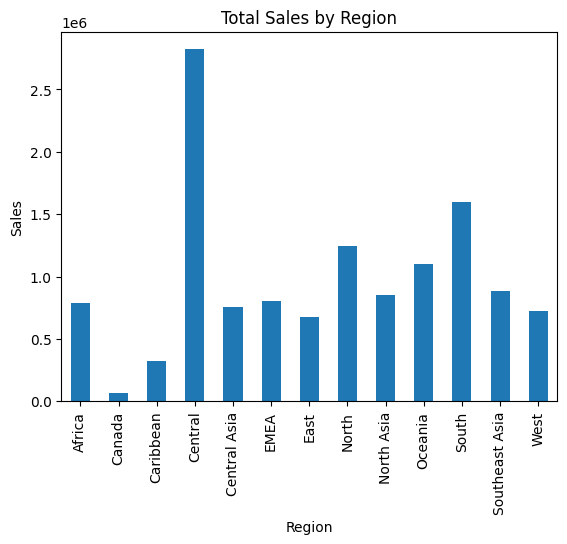

In [31]:
import matplotlib.pyplot as plt
region_sales.plot(kind = "bar")

plt.title("Total Sales by Region")
plt.ylabel("Sales")
plt.savefig("sales_by_region.png")
plt.show()

Profit by Category:

In [32]:
category_profit = df.groupby("Category")["Profit"].sum()
category_profit

,Profit
Category,
Furniture,285204.72380
Office Supplies,518473.83430
Technology,663778.73318


Visualization:

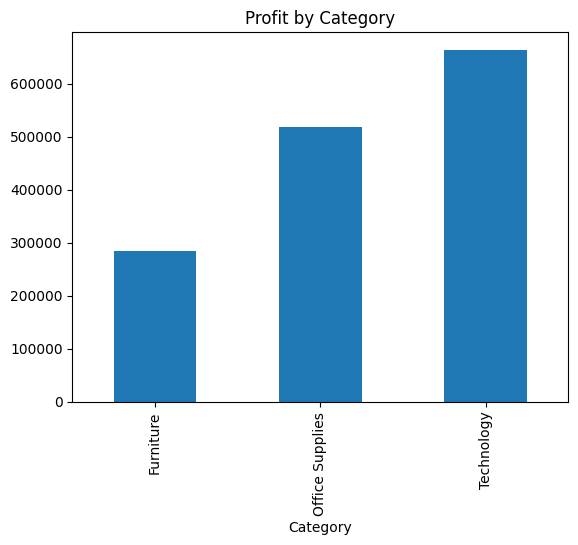

In [33]:
category_profit.plot(kind = "bar")
plt.title("Profit by Category")
plt.savefig("profit_by_category.png")
plt.show()

Monthly Sales Trend:

In [34]:
df["Month"] = df["Order Date"].dt.to_period("M")

In [35]:
# Calculate Revenue:
monthly_sales = df.groupby("Month")["Sales"].sum()
monthly_sales

,Sales
Month,
2011-01,98898.48886
2011-02,91152.15698
2011-03,145729.36736
2011-04,116915.76418
2011-05,146747.83610
2011-06,215207.38022
2011-07,115510.41912
2011-08,207581.49122
2011-09,290214.45534


Visualization:

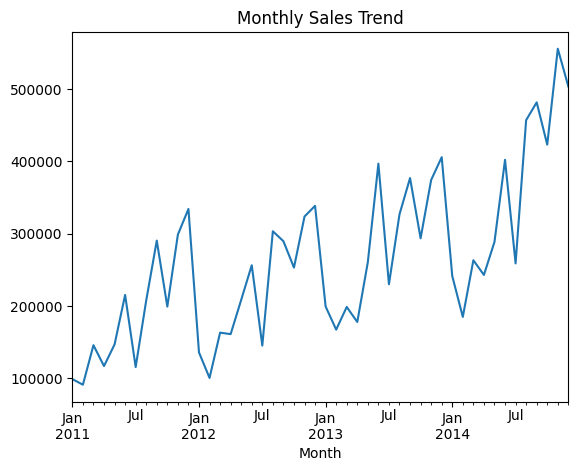

In [36]:
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.savefig("monthly_sales.png")
plt.show()

Top 10 Products:

In [37]:
top_products = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)
top_products

,Sales
Product Name,
"Apple Smart Phone, Full Size",86935.7786
"Cisco Smart Phone, Full Size",76441.5306
"Motorola Smart Phone, Full Size",73156.3030
"Nokia Smart Phone, Full Size",71904.5555
Canon imageCLASS 2200 Advanced Copier,61599.8240
"Hon Executive Leather Armchair, Adjustable",58193.4841
"Office Star Executive Leather Armchair, Adjustable",50661.6840
"Harbour Creations Executive Leather Armchair, Adjustable",50121.5160
"Samsung Smart Phone, Cordless",48653.4600


Visualization:

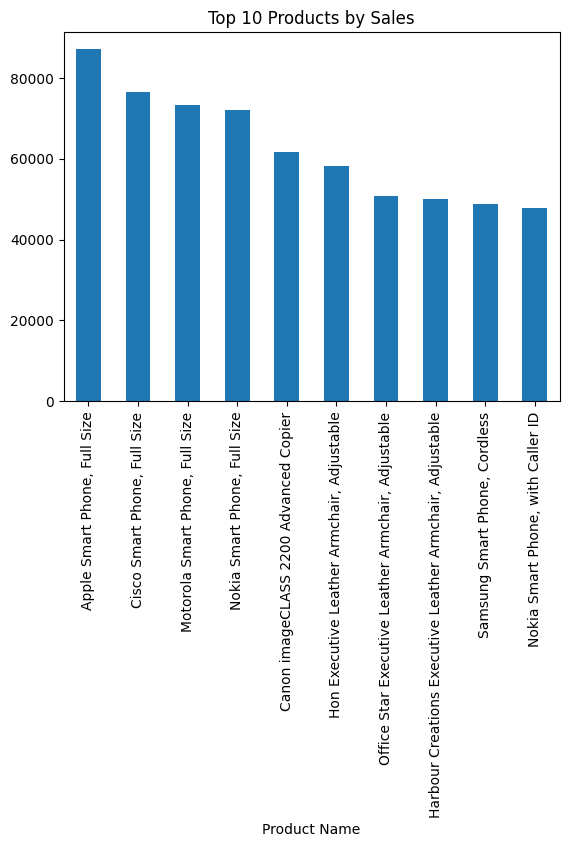

In [38]:
top_products.plot(kind= "bar")
plt.title("Top 10 Products by Sales")
plt.savefig("top_products.png")
plt.show()

**Business Insights**
1. The West region generates the highest revenue.
2. Technology products produce the highest profit.
3. Sales increase significantly during holidy months.
4. A small number of products contribute heavily to revenue.